**1. Import Libraries**

In [51]:

import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings 
warnings.filterwarnings('ignore')




**2. Upload the Dataset**

In [52]:
dataset=pd.read_csv('dataset/customs_inspection_dataset_final_30000.csv')
dataset

,Shipment_ID,Shipment_Date,Year,Month,Cargo_Season,Commodity_Type,Commodity_Risk_Level,Shipper_Company_Name,Shipper_Compliance_Score,Consignee_Company_Name,Consignee_Compliance_Score,Shipment_Value_USD,Weight_KG,Previous_Violations,Missing_Documents,Inspection_Required
0,SHP00001,2025-01-31,2025,1,Regular,Textiles,Low,Cotton Weave Industries,80,Riyadh Garment Trading,87,132932,5440,1,No,0
1,SHP00002,2025-05-23,2025,5,Regular,Consumer Goods,Low,Premium Consumer Goods,69,Saudi Retail Group,68,389468,11413,6,No,0
2,SHP00003,2024-03-16,2024,3,Ramadan,Pharmaceuticals,High,Sun Pharma Logistics,42,Riyadh Healthcare Imports,42,268455,5101,11,No,1
3,SHP00004,2024-12-18,2024,12,Year_End_Peak,Agricultural Products,Low,Green Farm Exports,83,Saudi Agriculture Imports,85,150503,2797,1,No,0
4,SHP00005,2025-06-21,2025,6,Hajj,Medical Equipment,High,Healthcare Equipment Exporters,49,Saudi Medical Equipment,51,274538,3606,6,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,SHP29996,2025-02-19,2025,2,Regular,Consumer Goods,Low,Premium Consumer Goods,69,Riyadh Retail Distribution,60,41263,13422,5,No,1
29996,SHP29997,2024-12-18,2024,12,Year_End_Peak,Electronics,Medium,Samsung Electronics Export,71,Jeddah Tech Distribution,77,428111,9409,3,No,0
29997,SHP29998,2024-04-22,2024,4,Eid,Machinery,Medium,Industrial Machinery Ltd,37,Jeddah Machinery Traders,49,108127,6813,11,No,1
29998,SHP29999,2022-12-20,2022,12,Year_End_Peak,Textiles,Low,ABC Textile Mills,94,Riyadh Garment Trading,87,197376,1673,1,No,0


In [53]:
# import random

# inspection_required = []

# for _, row in dataset.iterrows():

#     risk_score = 0

#     # =====================================================
#     # Commodity Risk Level (Highest Importance)
#     # =====================================================

#     if row["Commodity_Risk_Level"] == "High":
#         risk_score += 35

#     elif row["Commodity_Risk_Level"] == "Medium":
#         risk_score += 15

#     # =====================================================
#     # Previous Violations
#     # =====================================================

#     risk_score += min(
#         row["Previous_Violations"] * 4,
#         25
#     )

#     # =====================================================
#     # Missing Documents
#     # =====================================================

#     if row["Missing_Documents"] == "Yes":
#         risk_score += 20

#     # =====================================================
#     # Consignee Compliance Score
#     # =====================================================

#     if row["Consignee_Compliance_Score"] < 50:
#         risk_score += 20

#     elif row["Consignee_Compliance_Score"] < 70:
#         risk_score += 10

#     # =====================================================
#     # Shipper Compliance Score
#     # =====================================================

#     if row["Shipper_Compliance_Score"] < 50:
#         risk_score += 15

#     elif row["Shipper_Compliance_Score"] < 70:
#         risk_score += 8

#     # =====================================================
#     # Shipment Value
#     # =====================================================

#     if row["Shipment_Value_USD"] > 100000:
#         risk_score += 10

#     elif row["Shipment_Value_USD"] > 50000:
#         risk_score += 5

#     # =====================================================
#     # Cargo Season
#     # =====================================================

#     if row["Cargo_Season"] in [
#         "Ramadan",
#         "Hajj",
#         "Year_End_Peak"
#     ]:
#         risk_score += 5

#     # =====================================================
#     # Weight
#     # =====================================================

#     if row["Weight_KG"] > 5000:
#         risk_score += 3

#     # =====================================================
#     # Random Variation
#     # =====================================================

#     risk_score += random.randint(-5, 5)

#     # =====================================================
#     # Final Decision
#     # =====================================================

#     if risk_score >= 80:
#         inspection = 1
#     else:
#         inspection = 0

#     inspection_required.append(inspection)

# dataset["Inspection_Required"] = inspection_required

**3. Basic Checkups**

In [54]:
# Target Distribution
dataset["Inspection_Required"].value_counts()

Inspection_Required
0    23101
1     6899
Name: count, dtype: int64

In [55]:
# Shape
print("Shape of the dataset:")
print(dataset.shape)
print("\n")


# Columns
print("Columns in the dataset:")
print(dataset.columns)
print("\n")

#check the null values in the dataset
print("Null values in the dataset:")
print(dataset.isnull().sum())

Shape of the dataset:
(30000, 16)


Columns in the dataset:
Index(['Shipment_ID', 'Shipment_Date', 'Year', 'Month', 'Cargo_Season',
       'Commodity_Type', 'Commodity_Risk_Level', 'Shipper_Company_Name',
       'Shipper_Compliance_Score', 'Consignee_Company_Name',
       'Consignee_Compliance_Score', 'Shipment_Value_USD', 'Weight_KG',
       'Previous_Violations', 'Missing_Documents', 'Inspection_Required'],
      dtype='str')


Null values in the dataset:
Shipment_ID                   0
Shipment_Date                 0
Year                          0
Month                         0
Cargo_Season                  0
Commodity_Type                0
Commodity_Risk_Level          0
Shipper_Company_Name          0
Shipper_Compliance_Score      0
Consignee_Company_Name        0
Consignee_Compliance_Score    0
Shipment_Value_USD            0
Weight_KG                     0
Previous_Violations           0
Missing_Documents             0
Inspection_Required           0
dtype: int64


In [56]:
# Information about the dataset
print("Dataset Information:")
dataset.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Shipment_ID                 30000 non-null  str  
 1   Shipment_Date               30000 non-null  str  
 2   Year                        30000 non-null  int64
 3   Month                       30000 non-null  int64
 4   Cargo_Season                30000 non-null  str  
 5   Commodity_Type              30000 non-null  str  
 6   Commodity_Risk_Level        30000 non-null  str  
 7   Shipper_Company_Name        30000 non-null  str  
 8   Shipper_Compliance_Score    30000 non-null  int64
 9   Consignee_Company_Name      30000 non-null  str  
 10  Consignee_Compliance_Score  30000 non-null  int64
 11  Shipment_Value_USD          30000 non-null  int64
 12  Weight_KG                   30000 non-null  int64
 13  Previous_Violations         30000 non-null  int64
 

In [57]:
#statistical summary of the dataset
print("Statistical Summary of the Dataset:")
dataset.describe()

Statistical Summary of the Dataset:


,Year,Month,Shipper_Compliance_Score,Consignee_Compliance_Score,Shipment_Value_USD,Weight_KG,Previous_Violations,Inspection_Required
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2023.498300,6.479533,69.646567,73.116900,249058.146367,15041.623467,3.040767,0.229967
std,1.114587,3.454318,18.916236,13.739597,144048.007509,8658.971247,2.905223,0.420818
min,2022.000000,1.000000,31.000000,42.000000,1009.000000,50.000000,0.000000,0.000000
25%,2023.000000,3.000000,51.000000,60.000000,124631.500000,7603.000000,1.000000,0.000000
50%,2023.000000,6.000000,74.000000,77.000000,247948.000000,14965.000000,2.000000,0.000000
75%,2024.000000,9.000000,83.000000,83.000000,373509.750000,22616.250000,4.000000,0.000000
max,2025.000000,12.000000,99.000000,95.000000,499964.000000,29998.000000,15.000000,1.000000


**4. Exploratory Data Analysis**

4.1 Target Variable Analysis

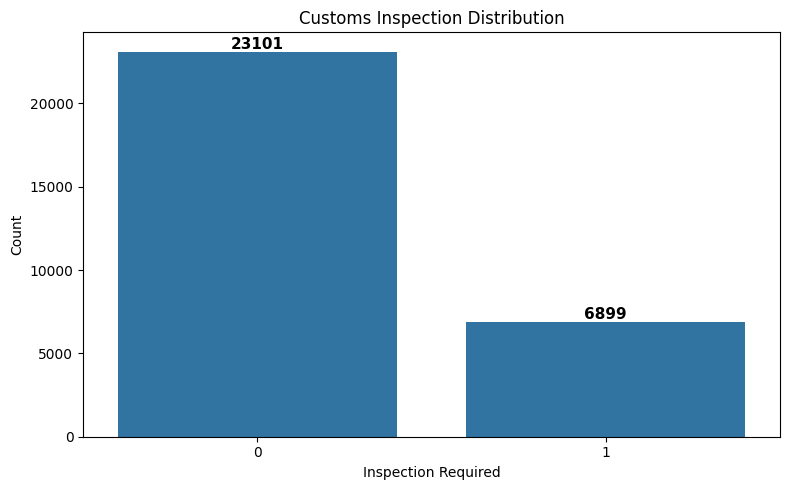

In [58]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=dataset,
    x='Inspection_Required'
)

plt.title('Customs Inspection Distribution')
plt.xlabel('Inspection Required')
plt.ylabel('Count')

# Show values above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

4.2 Distribution for numerical value

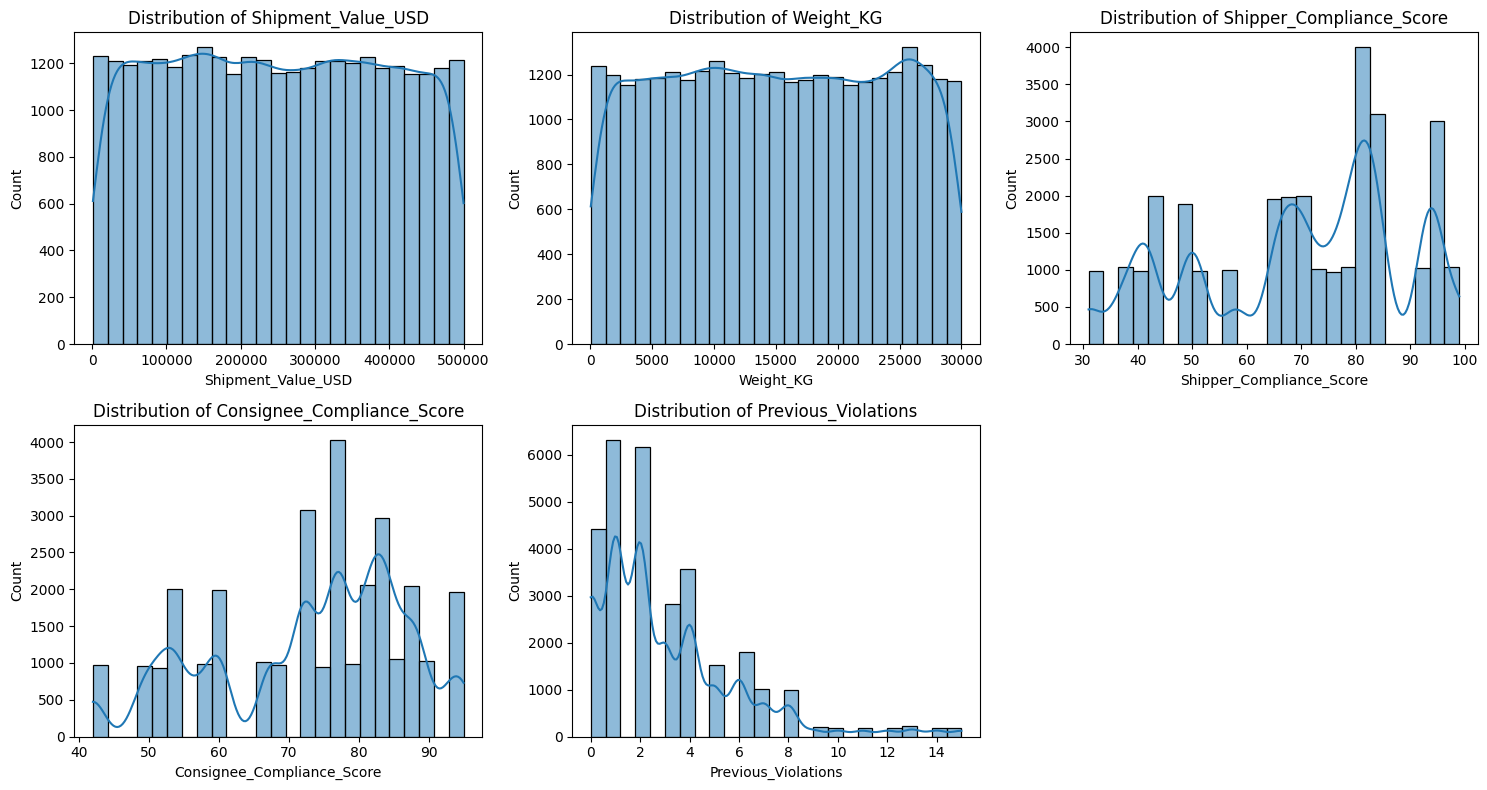

Shipment_Value_USD: 0.01
Weight_KG: -0.00
Shipper_Compliance_Score: -0.43
Consignee_Compliance_Score: -0.54
Previous_Violations: 1.60


In [59]:
numerical_cols = [
    "Shipment_Value_USD",
    "Weight_KG",
    "Shipper_Compliance_Score",
    "Consignee_Compliance_Score",
    "Previous_Violations"
]

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, n_rows * 4)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_cols):

    sns.histplot(
        dataset[feature],
        bins=25,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {feature}"
    )

    axes[i].set_xlabel(
        feature
    )

    axes[i].set_ylabel(
        "Count"
    )

# Hide empty plots
for j in range(len(numerical_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

for col in numerical_cols: 
    skew = dataset[col].skew()
    print(f"{col}: {skew:.2f}")

4.2.1 Handling sweked numerical data

Before: 1.6007175084167988
After: -0.026704539970716944


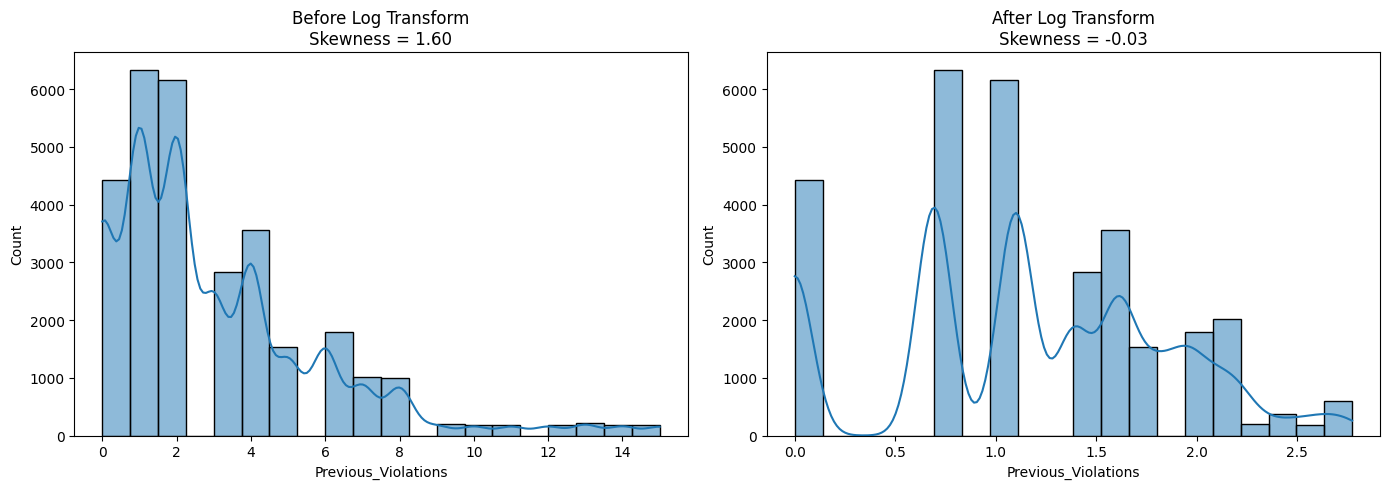

In [60]:
print(
    "Before:",
    dataset["Previous_Violations"].skew()
)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)
# Before
sns.histplot(
    dataset["Previous_Violations"],
    bins=20,
    kde=True,
    ax=axes[0]
)

axes[0].set_title(
    f"Before Log Transform\nSkewness = {dataset['Previous_Violations'].skew():.2f}"
)

dataset["Previous_Violations"] = np.log1p(
    dataset["Previous_Violations"]
)

print(
    "After:",
    dataset["Previous_Violations"].skew()
)

# After
sns.histplot(
    dataset["Previous_Violations"],
    bins=20,
    kde=True,
    ax=axes[1]
)

axes[1].set_title(
    f"After Log Transform\nSkewness = {dataset['Previous_Violations'].skew():.2f}"
)

plt.tight_layout()
plt.show()

4.3 Distribution for Categorical Values


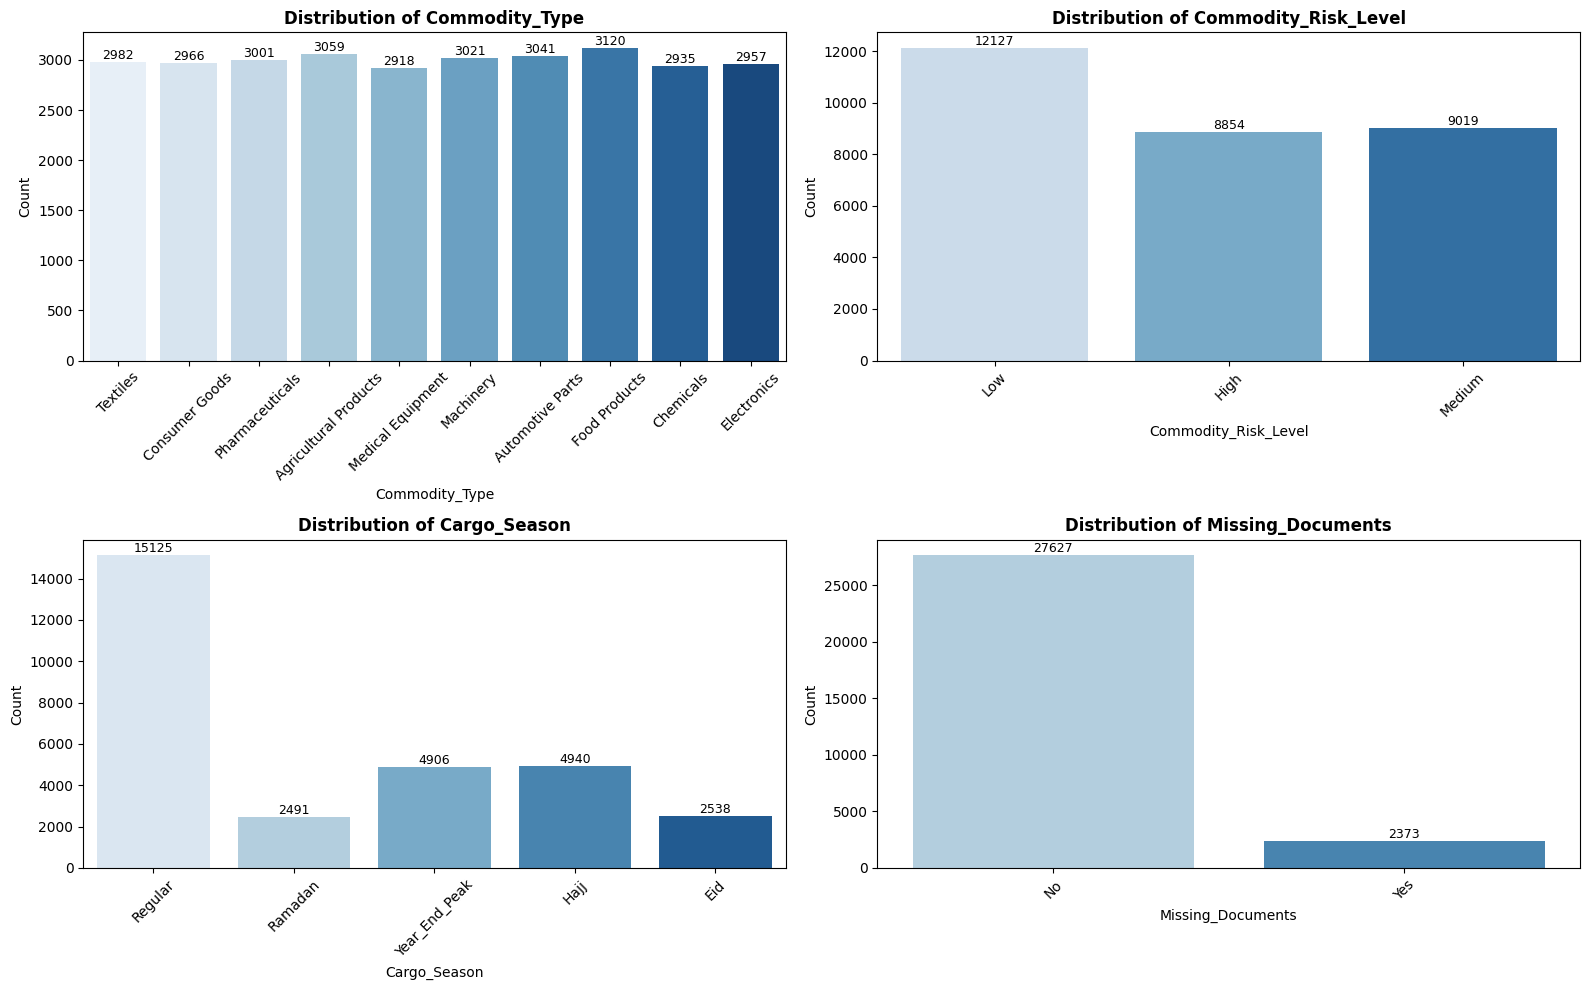

In [61]:
categorical_cols = [
    "Commodity_Type",
    "Commodity_Risk_Level",
    "Cargo_Season",
    "Missing_Documents"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = sns.countplot(
        data=dataset,
        x=col,
        ax=axes[i],
        palette="Blues"
    )

    axes[i].set_title(
        f"Distribution of {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    axes[i].tick_params(
        axis="x",
        rotation=45
    )

    # Add count labels above bars
    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%d",
            fontsize=9
        )

plt.tight_layout()
plt.show()



**5. Feature Engineering**


5.1 Dataset Spliting

In [62]:
drop_columns = ['Inspection_Required', 'Shipment_ID','Shipment_Date']

X = dataset.drop(drop_columns, axis=1)
y = dataset['Inspection_Required']

In [63]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [64]:
# Backup for CatBoost
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

y_train_cat = y_train.copy()
y_val_cat = y_val.copy()    
y_test_cat = y_test.copy()

In [65]:
print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (21000, 13)
Validation : (4500, 13)
Test : (4500, 13)


5.2 Encoding the Categorical Features

In [66]:
#categorical value for encoding
categorical_cols = X_train.select_dtypes(include='object').columns
print(categorical_cols)

Index(['Cargo_Season', 'Commodity_Type', 'Commodity_Risk_Level',
       'Shipper_Company_Name', 'Consignee_Company_Name', 'Missing_Documents'],
      dtype='str')


In [67]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col])
    
    label_encoders[col] = le

5.3 Standard Scaling for numeric Features

In [68]:
#numerical columns for Scaling
numerical_cols = X_train.select_dtypes(
    exclude='object'
).columns

numerical_cols


Index(['Year', 'Month', 'Cargo_Season', 'Commodity_Type',
       'Commodity_Risk_Level', 'Shipper_Company_Name',
       'Shipper_Compliance_Score', 'Consignee_Company_Name',
       'Consignee_Compliance_Score', 'Shipment_Value_USD', 'Weight_KG',
       'Previous_Violations', 'Missing_Documents'],
      dtype='str')

In [69]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train_scaled[numerical_cols]
)

X_val_scaled[numerical_cols] = scaler.transform(
    X_val_scaled[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test_scaled[numerical_cols]
)

**6. Model Building**

6.1 Logistic Regression

In [70]:
###Grid Search for Logistic Regression###

# lr_param_grid = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'penalty': ['l1', 'l2'],
#     'solver': ['liblinear']
# }

# lr_grid = GridSearchCV(
#     estimator=LogisticRegression(
#         random_state=42,
#         max_iter=1000,
#         class_weight='balanced'
#     ),
#     param_grid=lr_param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1
# )

# lr_grid.fit(X_train_scaled, y_train)

# print("Best Parameters:")
# print(lr_grid.best_params_)

# print("\nBest F1 Score:")
# print(lr_grid.best_score_)

In [71]:
lr_model = LogisticRegression(

    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train_scaled,y_train)
y_prob_lr= lr_model.predict_proba(X_val_scaled)[:, 1]

threshold = 0.50

y_val_pred_lr = (y_prob_lr > threshold).astype(int)
print("Logistic Regression Model Trained Successfully")



Logistic Regression Model Trained Successfully


In [72]:
# Accuracy
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)

# Precision
lr_precision = precision_score(y_val, y_val_pred_lr)

# Recall
lr_recall = recall_score(y_val, y_val_pred_lr)

# F1 Score
lr_f1 = f1_score(y_val, y_val_pred_lr)

# Print metrics
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_lr))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lr))

Accuracy : 0.9051111111111111
Precision: 0.7306525037936267
Recall   : 0.9304347826086956
F1 Score : 0.8185295367615809

Confusion Matrix:

[[3110  355]
 [  72  963]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.90      0.94      3465
           1       0.73      0.93      0.82      1035

    accuracy                           0.91      4500
   macro avg       0.85      0.91      0.88      4500
weighted avg       0.92      0.91      0.91      4500



6.2 Decision tree

In [73]:
###Grid Search for Decision Tree###

# dt_param_grid = {
#     'max_depth': [3, 5, 7, 10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'criterion': ['gini', 'entropy']
# }

# dt_grid = GridSearchCV(
#     estimator=DecisionTreeClassifier(
#         random_state=42,
#         class_weight='balanced'
#     ),
#     param_grid=dt_param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1
# )

# dt_grid.fit(X_train, y_train)

# print("Best Parameters:")
# print(dt_grid.best_params_)

# print("\nBest F1 Score:")
# print(dt_grid.best_score_)

In [74]:
# Initialize model
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

# Train model
dt_model.fit(X_train, y_train)

# Validation prediction
y_prob_dt = dt_model.predict_proba(X_val)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_dt = (y_prob_dt > threshold).astype(int)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [75]:
# Accuracy
dt_accuracy = accuracy_score(y_val, y_val_pred_dt)

# Precision
dt_precision = precision_score(y_val, y_val_pred_dt)

# Recall
dt_recall = recall_score(y_val, y_val_pred_dt)

# F1 Score
dt_f1 = f1_score(y_val, y_val_pred_dt)

# Print metrics
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_dt))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_dt))

Accuracy : 0.9475555555555556
Precision: 0.8830297219558965
Recall   : 0.8898550724637682
F1 Score : 0.8864292589027911

Confusion Matrix:

[[3343  122]
 [ 114  921]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3465
           1       0.88      0.89      0.89      1035

    accuracy                           0.95      4500
   macro avg       0.93      0.93      0.93      4500
weighted avg       0.95      0.95      0.95      4500



6.3 Random Forest

In [76]:
# ##Grid Search for Random Forest###

# rf_param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'max_features': ['sqrt']
# }

# rf_grid = GridSearchCV(
#     estimator=RandomForestClassifier(
#         random_state=42,
#         class_weight='balanced',
#         n_jobs=-1
#     ),
#     param_grid=rf_param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1
# )

# rf_grid.fit(X_train, y_train)

# print("Best Parameters:")
# print(rf_grid.best_params_)

# print("\nBest F1 Score:")
# print(rf_grid.best_score_)

In [77]:
# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

# Train model
rf_model.fit(X_train, y_train)

# Validation prediction
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# Custom threshold
threshold = 0.45

# Apply threshold
y_val_pred_rf = (y_prob_rf > threshold).astype(int)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [78]:
# Accuracy
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)

# Precision
rf_precision = precision_score(y_val, y_val_pred_rf)

# Recall
rf_recall = recall_score(y_val, y_val_pred_rf)

# F1 Score
rf_f1 = f1_score(y_val, y_val_pred_rf)

# Print Metrics
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_rf))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_rf))

Accuracy : 0.9546666666666667
Precision: 0.9037900874635568
Recall   : 0.8985507246376812
F1 Score : 0.9011627906976745

Confusion Matrix:

[[3366   99]
 [ 105  930]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3465
           1       0.90      0.90      0.90      1035

    accuracy                           0.95      4500
   macro avg       0.94      0.93      0.94      4500
weighted avg       0.95      0.95      0.95      4500



6.4 XGBoost Classifier

In [79]:
###Random Search for XGBoost###

# xgb_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7, 10],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9, 1.0],
#     'min_child_weight': [1, 3, 5]
# }

# xgb_random = RandomizedSearchCV(
#     estimator=XGBClassifier(
#         objective='binary:logistic',
#         eval_metric='logloss',
#         random_state=42
#     ),
#     param_distributions=xgb_param_grid,
#     n_iter=20,
#     scoring='f1',
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_random.fit(X_train, y_train)

# print("Best Parameters:")
# print(xgb_random.best_params_)

# print("\nBest F1 Score:")
# print(xgb_random.best_score_)

In [80]:
# Tuned XGBoost with imbalance handling
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=1.0,
    gamma=0.1,
    random_state=42,
)

# Train model
xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_xgb = (y_prob_xgb > threshold).astype(int)

print("Tuned XGBoost Model Trained Successfully")

Tuned XGBoost Model Trained Successfully


In [81]:
# Accuracy
xgb_accuracy = accuracy_score(y_val, y_val_pred_xgb)

# Precision
xgb_precision = precision_score(y_val, y_val_pred_xgb)

# Recall
xgb_recall = recall_score(y_val, y_val_pred_xgb)

# F1 Score
xgb_f1 = f1_score(y_val, y_val_pred_xgb)

# Print Metrics
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_xgb))

Accuracy : 0.9597777777777777
Precision: 0.9348268839103869
Recall   : 0.8869565217391304
F1 Score : 0.9102627664848786

Confusion Matrix:

[[3401   64]
 [ 117  918]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3465
           1       0.93      0.89      0.91      1035

    accuracy                           0.96      4500
   macro avg       0.95      0.93      0.94      4500
weighted avg       0.96      0.96      0.96      4500



6.5 LightGBM

In [82]:
# ##Random Search for LightGBM###

# lgbm_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7, 10],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'num_leaves': [15, 31, 63],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9, 1.0]
# }

# lgbm_random = RandomizedSearchCV(
#     estimator=LGBMClassifier(
#         random_state=42,
#         class_weight='balanced',
#         verbose=-1
#     ),
#     param_distributions=lgbm_param_grid,
#     n_iter=20,
#     scoring='f1',
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# lgbm_random.fit(X_train, y_train)

# print("Best Parameters:")
# print(lgbm_random.best_params_)

# print("\nBest F1 Score:")
# print(lgbm_random.best_score_)

In [83]:
# Initialize model
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=15,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42
)
# Train model
lgbm_model.fit(X_train, y_train)

# Predict probabilities
y_prob_lgbm = lgbm_model.predict_proba(X_val)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_lgbm = (y_prob_lgbm > threshold).astype(int)


print("LightGBM Model Trained Successfully")

[LightGBM] [Info] Number of positive: 4829, number of negative: 16171
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000335 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM Model Trained Successfully


In [84]:
# Accuracy
lgbm_accuracy = accuracy_score(y_val, y_val_pred_lgbm)

# Precision
lgbm_precision = precision_score(y_val, y_val_pred_lgbm)

# Recall
lgbm_recall = recall_score(y_val, y_val_pred_lgbm)

# F1 Score
lgbm_f1 = f1_score(y_val, y_val_pred_lgbm)

# Print Metrics
print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_lgbm))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lgbm))

Accuracy : 0.9562222222222222
Precision: 0.8982889733840305
Recall   : 0.9130434782608695
F1 Score : 0.9056061332055583

Confusion Matrix:

[[3358  107]
 [  90  945]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3465
           1       0.90      0.91      0.91      1035

    accuracy                           0.96      4500
   macro avg       0.94      0.94      0.94      4500
weighted avg       0.96      0.96      0.96      4500



6.6 CATBoost Classifier

In [85]:
cat_features = X_train_cat.select_dtypes(
    include=['object', 'category']
).columns.tolist()


In [86]:
# # Random Search for CatBoost ###

# cat_param_grid = {
#     'iterations': [100, 200, 300],
#     'depth': [4, 6, 8, 10],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'l2_leaf_reg': [1, 3, 5, 7, 9]
# }

# cat_random = RandomizedSearchCV(
#     estimator=CatBoostClassifier(
#         random_state=42,
#         verbose=0
#     ),
#     param_distributions=cat_param_grid,
#     n_iter=20,
#     scoring='f1',
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# cat_random.fit(X_train_cat, y_train,cat_features=cat_features)

# print("Best Parameters:")
# print(cat_random.best_params_)

# print("\nBest F1 Score:")
# print(cat_random.best_score_)

In [87]:
# Initialize Model
cat_model = CatBoostClassifier(
    iterations=300,
    depth=10,
    l2_leaf_reg=7,
    learning_rate=0.05,
    loss_function='MultiClass',
    random_state=42,
    verbose=0
)

# Train Model
cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_features
)

# Validation Prediction
y_val_pred_cat = cat_model.predict(X_val_cat)

# Convert prediction shape
y_val_pred_cat = y_val_pred_cat.flatten()

print("CatBoost Model Trained Successfully")

CatBoost Model Trained Successfully


In [88]:
# Accuracy
cat_accuracy = accuracy_score(
    y_val_cat,
    y_val_pred_cat
)

# Precision
cat_precision = precision_score(
    y_val_cat,
    y_val_pred_cat
)

# Recall
cat_recall = recall_score(
    y_val_cat,
    y_val_pred_cat
)

# F1 Score
cat_f1 = f1_score(
    y_val_cat,
    y_val_pred_cat
)

print("Accuracy :", cat_accuracy)
print("Precision :", cat_precision)
print("Recall :", cat_recall)
print("F1 Score :", cat_f1)

print("\nConfusion Matrix:\n")
print(
    confusion_matrix(
        y_val_cat,
        y_val_pred_cat
    )
)

print("\nClassification Report:\n")
print(
    classification_report(
        y_val_cat,
        y_val_pred_cat
    )
)

Accuracy : 0.96
Precision : 0.9313824419778002
Recall : 0.8917874396135266
F1 Score : 0.9111549851924975

Confusion Matrix:

[[3397   68]
 [ 112  923]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3465
           1       0.93      0.89      0.91      1035

    accuracy                           0.96      4500
   macro avg       0.95      0.94      0.94      4500
weighted avg       0.96      0.96      0.96      4500



**7. Model Comparision**

In [89]:
# Create Model Comparison Table

model_results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest','XGBoost','LightGBM','CatBoost'],
    'Accuracy': [lr_accuracy,dt_accuracy,rf_accuracy,xgb_accuracy,lgbm_accuracy,cat_accuracy],
    'Precision': [lr_precision,dt_precision,rf_precision, xgb_precision,lgbm_precision,cat_precision],
    'Recall': [lr_recall, dt_recall, rf_recall, xgb_recall, lgbm_recall,cat_recall],
    'F1 Score': [lr_f1, dt_f1, rf_f1, xgb_f1,lgbm_f1,cat_f1]
})

# Sort by F1 Score
model_results = model_results.sort_values(
    by='F1 Score',
    ascending=False
)

# Display
print(model_results)

                 Model  Accuracy  Precision    Recall  F1 Score
5             CatBoost  0.960000   0.931382  0.891787  0.911155
3              XGBoost  0.959778   0.934827  0.886957  0.910263
4             LightGBM  0.956222   0.898289  0.913043  0.905606
2        Random Forest  0.954667   0.903790  0.898551  0.901163
1        Decision Tree  0.947556   0.883030  0.889855  0.886429
0  Logistic Regression  0.905111   0.730653  0.930435  0.818530


**8. Save the Model**

In [90]:
import joblib

joblib.dump(
    cat_model,
    "model/customs_inspection_cat_model.pkl"
)
print("Model Saved Successfully")

joblib.dump(
    X_train.columns.tolist(),
    "model/feature_columns.pkl"
)
print("Feature Columns Saved")

joblib.dump(
    label_encoders,
    "model/label_encoders.pkl"
)
print("Label Encoders Saved")

Model Saved Successfully
Feature Columns Saved
Label Encoders Saved


In [91]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)


                       Feature  Importance
9           Shipment_Value_USD   12.588817
11         Previous_Violations   12.225283
8   Consignee_Compliance_Score   10.987685
4         Commodity_Risk_Level   10.333014
6     Shipper_Compliance_Score    9.616002
12           Missing_Documents    6.927017
10                   Weight_KG    6.848499
1                        Month    6.574598
2                 Cargo_Season    6.116005
7       Consignee_Company_Name    5.094960
0                         Year    4.918148
5         Shipper_Company_Name    4.340213
3               Commodity_Type    3.429759


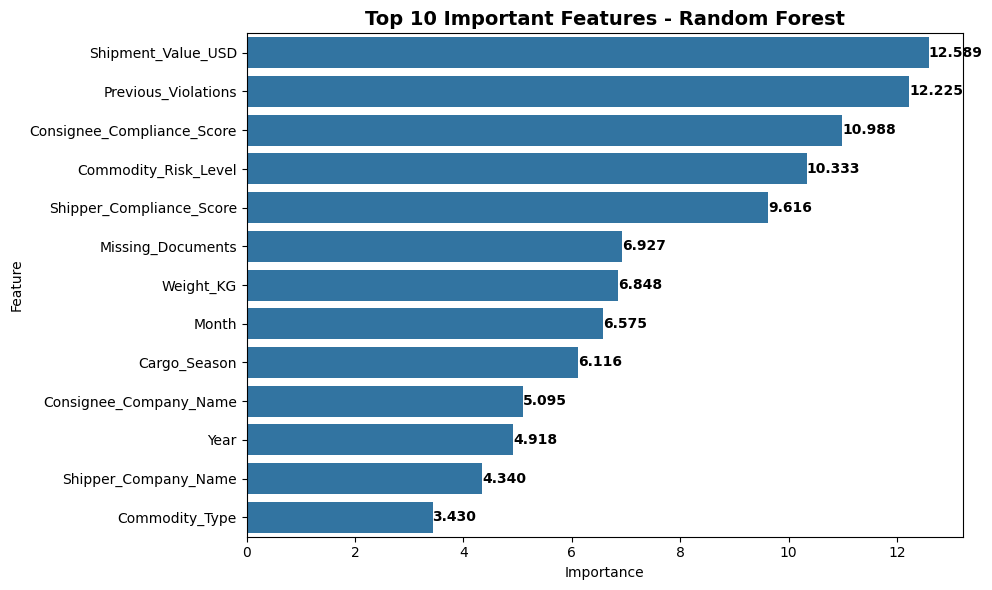

In [92]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Important Features - Random Forest',
    fontsize=14,
    fontweight='bold'
)

# Show values on bars
for i, value in enumerate(top_features['Importance']):
    plt.text(
        value,
        i,
        f'{value:.3f}',
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()